In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

In [92]:
df = pd.read_csv('veri.csv')

In [94]:
print("Veri Seti Boyutu (Satır, Sütun):", df.shape)
display(df.head())

Veri Seti Boyutu (Satır, Sütun): (10800, 15)


,Meter_Id,Date,Region_Code,Dwelling_Type,Num_Occupants,House_Area (sqft),Appliance_Score,Connected_Load(kw),Temperature_C,Humidity (%),Expected_Energy(kwh),Actual_Energy(kwh),Usage_Deviation(%),Cluster_Avg_Energy(kwh),Abnormal_Usage
0,IN-KL-ELC-97400511,25-01-2023,IN_KL_TVM,Independent House,2,2458,6,7.21,29.52,83.53,12.82 kWh,19.886033739870022 kWh,55.12,16.89,1
1,IN-KL-ELC-28113115,04-01-2023,IN_KL_ALP,Independent House,3,2295,9,7.98,25.83,48.79,14.66 kWh,15.51 kWh,5.80,17.83,0
2,IN-KL-ELC-17499006,04-01-2023,IN_KL_TVM,Apartment,3,2424,16,5.47,31.91,46.66,16.67 kWh,15.11 kWh,-9.36,17.26,0
3,IN-KL-ELC-22187937,21-01-2023,IN_KL_ERN,Apartment,1,2787,18,5.41,21.15,58.49,12.71 kWh,21.26104008352499 kWh,67.28,16.61,1
4,IN-KL-ELC-57403818,28-01-2023,IN_KL_ERN,Independent House,4,2389,10,2.99,30.91,77.26,13.53 kWh,12.67 kWh,-6.36,16.43,0


In [96]:
# 1. Eksik veri (Missing Values) kontrolü
print("Sütunlardaki Eksik Veri Sayıları:")
print(df.isnull().sum())

# 2. Tekrar eden (Duplicate) satır kontrolü
print("\nTekrar Eden Satır Sayısı:", df.duplicated().sum())

# 3. Sayısal verilerin istatistiksel özeti (Ortalama, min, max değerleri)
# .T (Transpose) ile tabloyu yan çevirip daha okunaklı hale getiriyoruz
display(df.describe().T)

Sütunlardaki Eksik Veri Sayıları:
Meter_Id                     0
Date                         0
Region_Code                  0
Dwelling_Type                0
Num_Occupants                0
House_Area (sqft)            0
Appliance_Score              0
Connected_Load(kw)           0
Temperature_C                0
Humidity (%)                 0
Expected_Energy(kwh)       667
Actual_Energy(kwh)         900
Usage_Deviation(%)           0
Cluster_Avg_Energy(kwh)      0
Abnormal_Usage               0
dtype: int64

Tekrar Eden Satır Sayısı: 0


,count,mean,std,min,25%,50%,75%,max
Num_Occupants,10800.0,3.527778,1.701159,1.00,2.0000,4.000,5.0000,6.00
House_Area (sqft),10800.0,1673.255556,708.161742,450.00,1003.2500,1775.500,2279.5000,2795.00
Appliance_Score,10800.0,13.508333,4.731902,6.00,9.0000,14.000,18.0000,21.00
Connected_Load(kw),10800.0,5.314472,1.546343,2.51,3.9200,5.335,6.6625,7.98
Temperature_C,10800.0,29.954353,3.992592,12.87,27.3075,29.970,32.6500,45.25
Humidity (%),10800.0,64.754650,11.491137,45.00,54.7775,64.525,74.6325,85.00
Usage_Deviation(%),10800.0,15.802278,26.914769,-37.24,-2.4925,4.025,33.0000,134.61
Cluster_Avg_Energy(kwh),10800.0,16.775722,0.499606,16.02,16.4300,16.610,16.9825,17.83
Abnormal_Usage,10800.0,0.438796,0.496263,0.00,0.0000,0.000,1.0000,1.00


Veri setinde eksik veri analizi yapılmış ve istatistiksel dağılımlar incelenmiştir.

In [100]:
# Sadece eksik olan sütunları ve sayılarını görelim
eksik_veriler = df.isnull().sum()
print("Doldurulmadan Önce Eksik Veriler:\n", eksik_veriler[eksik_veriler > 0])

# Sayısal sütunlardaki eksik verileri, o sütunun medyanı ile dolduruyoruz
df.fillna(df.median(numeric_only=True), inplace=True)

# İşlemin başarılı olup olmadığını kontrol edelim
print("\nKalan Toplam Eksik Veri Sayısı:", df.isnull().sum().sum())

Doldurulmadan Önce Eksik Veriler:
 Expected_Energy(kwh)    667
Actual_Energy(kwh)      900
dtype: int64

Kalan Toplam Eksik Veri Sayısı: 1567


### 1. Veri Ön İşleme ve Temizlik
Veri setinde yapılan sağlık taramasında 1567 adet eksik veri (NaN) tespit edilmiştir. 
Veri kaybını önlemek amacıyla, bu eksik değerler ilgili sütunların medyan (median) 
değerleri ile doldurulmuştur. Medyan tercihi, verideki olası uç değerlerin (outliers) 
ortalama üzerindeki saptırıcı etkisini engellemek için yapılmıştır.

In [104]:
# 1. Sayısal sütunları seç ve eksikleri medyan ile doldur
sayisal_sutunlar = df.select_dtypes(include=['number']).columns
df[sayisal_sutunlar] = df[sayisal_sutunlar].fillna(df[sayisal_sutunlar].median())

# 2. Metin/Kategorik sütunları seç ve eksikleri en çok tekrar eden (mod) ile doldur
kategorik_sutunlar = df.select_dtypes(exclude=['number']).columns
for sutun in kategorik_sutunlar:
    df[sutun] = df[sutun].fillna(df[sutun].mode()[0])

# 3. Son kontrol
print("Kalan Toplam Eksik Veri Sayısı:", df.isnull().sum().sum())

Kalan Toplam Eksik Veri Sayısı: 0


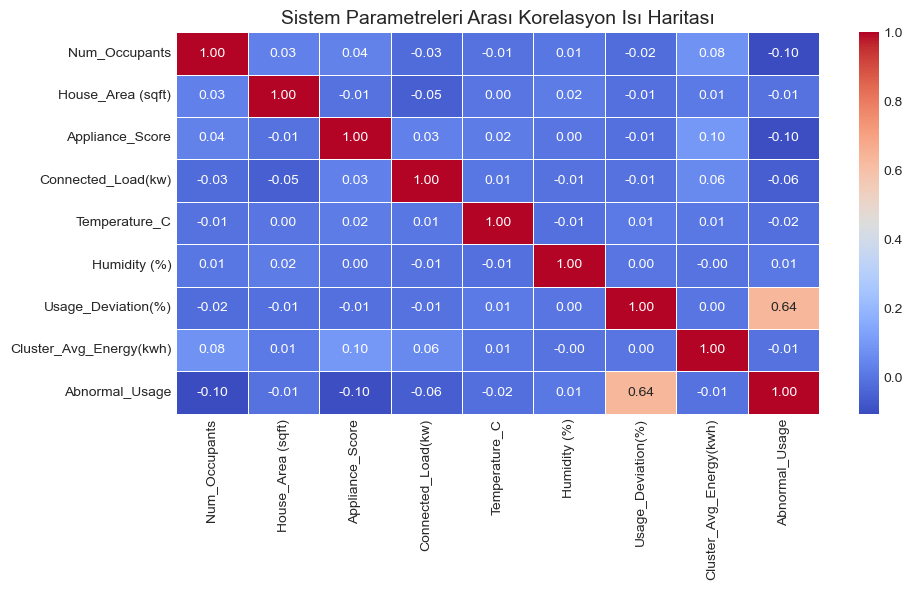

In [106]:
# Korelasyon Isı Haritası (Heatmap)
plt.figure(figsize=(10, 6))

# Sadece sayısal verilerin korelasyonunu hesaplıyoruz
sayisal_df = df.select_dtypes(include=['number'])
korelasyon_matrisi = sayisal_df.corr()

# Haritayı çizdiriyoruz
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sistem Parametreleri Arası Korelasyon Isı Haritası', fontsize=14)
plt.tight_layout()
plt.show()

In [108]:
print(df.columns)

Index(['Meter_Id', 'Date', 'Region_Code', 'Dwelling_Type', 'Num_Occupants',
       'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)',
       'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)',
       'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)',
       'Abnormal_Usage'],
      dtype='object')


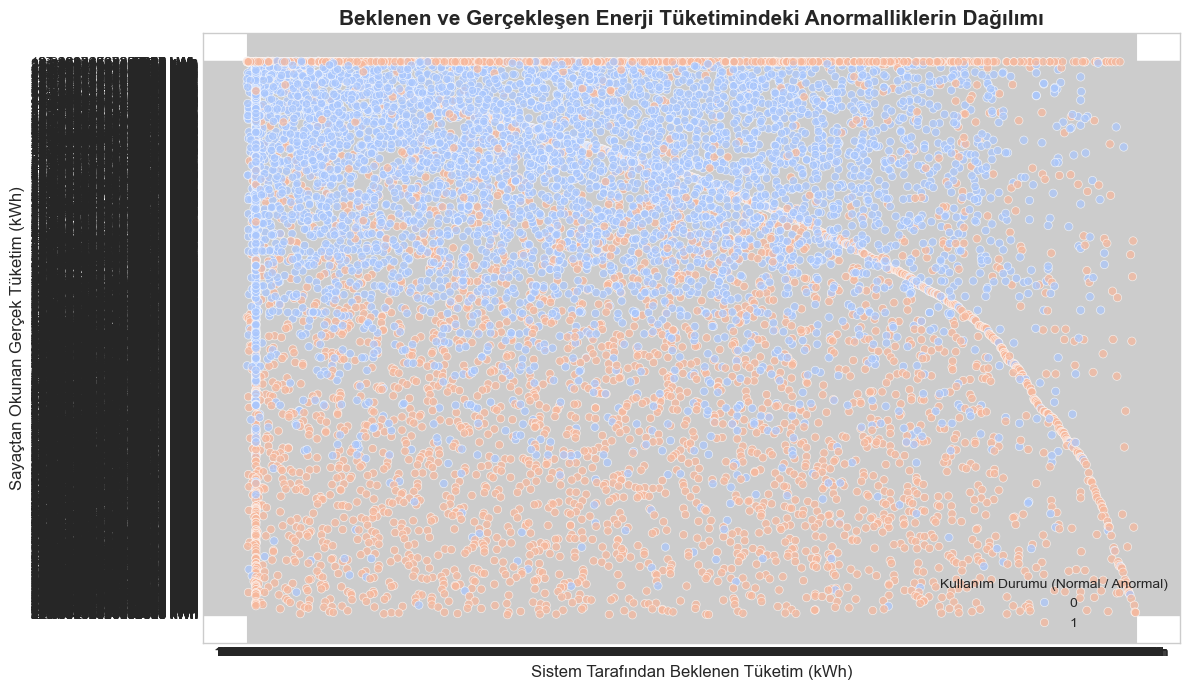

In [110]:
# Beklenen vs Gerçekleşen Enerji Tüketimi (Anormallik Tespiti Görselleştirmesi)
plt.figure(figsize=(12, 7))

# hue='Abnormal_Usage' parametresi, anormallik durumuna göre noktaları farklı renklere boyar
sns.scatterplot(x='Expected_Energy(kwh)', 
                y='Actual_Energy(kwh)', 
                hue='Abnormal_Usage', 
                data=df, 
                palette='coolwarm', 
                alpha=0.7)

# Grafiği makyajlama
plt.title('Beklenen ve Gerçekleşen Enerji Tüketimindeki Anormalliklerin Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Sistem Tarafından Beklenen Tüketim (kWh)', fontsize=12)
plt.ylabel('Sayaçtan Okunan Gerçek Tüketim (kWh)', fontsize=12)
plt.legend(title='Kullanım Durumu (Normal / Anormal)')
plt.tight_layout()
plt.show()

2.1. Beklenen ve Gerçekleşen Tüketim Analizi
Yukarıdaki saçılım grafiğinde, sistemin tahmin ettiği enerji yükü ile gerçekleşen tüketim değerleri karşılaştırılmıştır. Renklendirme anormallik durumuna (Abnormal_Usage) göre yapılmıştır. Bu görselleştirme, makine öğrenmesi modelimizin sınıflandırma yaparken (Classification) hangi sınır çizgilerini (decision boundaries) öğreneceği konusunda bize güçlü bir ön bilgi sunmaktadır

In [165]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Özellikler (X) ve Hedef Değişken (y) Ayrımı
# Modelin kafasını karıştırmamak için sadece sayısal verileri alıp, hedef değişkenimizi (Abnormal_Usage) X'ten çıkarıyoruz.
X = df.select_dtypes(include=['number']).drop('Abnormal_Usage', axis=1)
y = df['Abnormal_Usage']

# 2. Eğitim (Train) ve Test Veri Seti Ayrımı (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli Tanımlama ve Eğitme (Training)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Test Verisi Üzerinde Tahmin Yapma (Prediction)
y_pred = rf_model.predict(X_test)

# 5. Model Başarısını Ölçme
print("🎯 Model Doğruluk Skoru (Accuracy): %", round(accuracy_score(y_test, y_pred) * 100, 2))
print("\n📊 Detaylı Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))

🎯 Model Doğruluk Skoru (Accuracy): % 91.06

📊 Detaylı Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1203
           1       0.98      0.82      0.89       957

    accuracy                           0.91      2160
   macro avg       0.92      0.90      0.91      2160
weighted avg       0.92      0.91      0.91      2160



3. Makine Öğrenmesi Modeli (Random Forest Classifier)
Veri setindeki anormallikleri tespit etmek amacıyla Random Forest algoritması kullanılmıştır. Veri seti, aşırı öğrenmeyi (overfitting) engellemek adına %80 Eğitim ve %20 Test olacak şekilde ikiye ayrılmıştır. Kategorik ve kimlik (ID) belirten veriler modelin dışında bırakılarak saf sensör/tüketim metrikleri üzerinden bir sınıflandırma hedeflenmiştir.

In [168]:
import joblib

# Eğittiğimiz modeli '.pkl' formatında kaydediyoruz
joblib.dump(rf_model, 'anormallik_modeli.pkl')

print("Model başarıyla kaydedildi! Dosya adı: anormallik_modeli.pkl")

Model başarıyla kaydedildi! Dosya adı: anormallik_modeli.pkl
